In [16]:
# ============================================================
# CHUNK 0: Setup & Download Bitcoin Data from Kaggle
# ============================================================
#!pip install prophet kagglehub -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

FIGURES_DIR = os.path.join('outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Avoid re-downloading if already cached locally
_cache_base = os.path.join(os.path.expanduser("~"), ".cache", "kagglehub",
                           "datasets", "mczielinski", "bitcoin-historical-data", "versions")

if os.path.isdir(_cache_base) and os.listdir(_cache_base):
    _ver = sorted(os.listdir(_cache_base))[-1]          # highest version dir
    _candidate = os.path.join(_cache_base, _ver)
    if os.path.exists(os.path.join(_candidate, 'btcusd_1-min_data.csv')):
        path = _candidate
        print(f"Using cached dataset: {path}")
    else:
        import kagglehub
        path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
else:
    import kagglehub
    path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

print("Path to dataset files:", path)
for f in os.listdir(path):
    print(f" → {f}")

# Load CSV into DataFrame
raw_df = pd.read_csv(os.path.join(path, 'btcusd_1-min_data.csv'))
print(f"raw_df shape: {raw_df.shape}")
print(raw_df.head(3))

Using cached dataset: C:\Users\carlo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\525
Path to dataset files: C:\Users\carlo\.cache\kagglehub\datasets\mczielinski\bitcoin-historical-data\versions\525
 → btcusd_1-min_data.csv
raw_df shape: (7448799, 6)
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0


In [17]:
# ============================================================
# EXERCISE 1: Data Cleaning and Preprocessing
# ============================================================
# We adapt the energy-consumption cleaning pipeline to Bitcoin price data.
# "Close" price (USDT) replaces "MW" as our target variable.

# 1a. Convert Datetime column & set as index
df = raw_df.copy()
df['Datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('Datetime')
df = df.sort_index()
print(f"Shape after import: {df.shape}")

# 1b. Identify and handle duplicates (mean for duplicate timestamps)
dupes = df.index.duplicated(keep=False)
print(f"Duplicate timestamps found: {dupes.sum()}")
df = df.groupby(df.index).mean()
print(f"Shape after dedup:  {df.shape}")

# 1c. Force hourly frequency and fill gaps
# This is CRUCIAL: ensures a continuous hourly time series with no holes.
df = df.asfreq('h')
missing_before = df['Close'].isna().sum()
print(f"Missing hours after forcing freq: {missing_before}")

# Fill gaps using linear interpolation (better than ffill for price data)
df['Close'] = df['Close'].interpolate(method='linear')
missing_after = df['Close'].isna().sum()
print(f"Missing after interpolation: {missing_after}")

print(f"\nCleaned dataset: {df.shape[0]} hourly observations")
print(f"From {df.index.min()} to {df.index.max()}")
df.head(10)

Shape after import: (7448799, 6)
Duplicate timestamps found: 0
Shape after dedup:  (7448799, 6)
Missing hours after forcing freq: 20
Missing after interpolation: 0

Cleaned dataset: 124166 hourly observations
From 2012-01-01 10:01:00 to 2026-03-01 23:01:00


,Timestamp,Open,High,Low,Close,Volume
Datetime,,,,,,
2012-01-01 10:01:00,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 11:01:00,1.325416e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 12:01:00,1.325419e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 13:01:00,1.325423e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 14:01:00,1.325426e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 15:01:00,1.325430e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 16:01:00,1.325434e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 17:01:00,1.325437e+09,4.58,4.58,4.58,4.58,0.0
2012-01-01 18:01:00,1.325441e+09,4.58,4.58,4.58,4.58,0.0


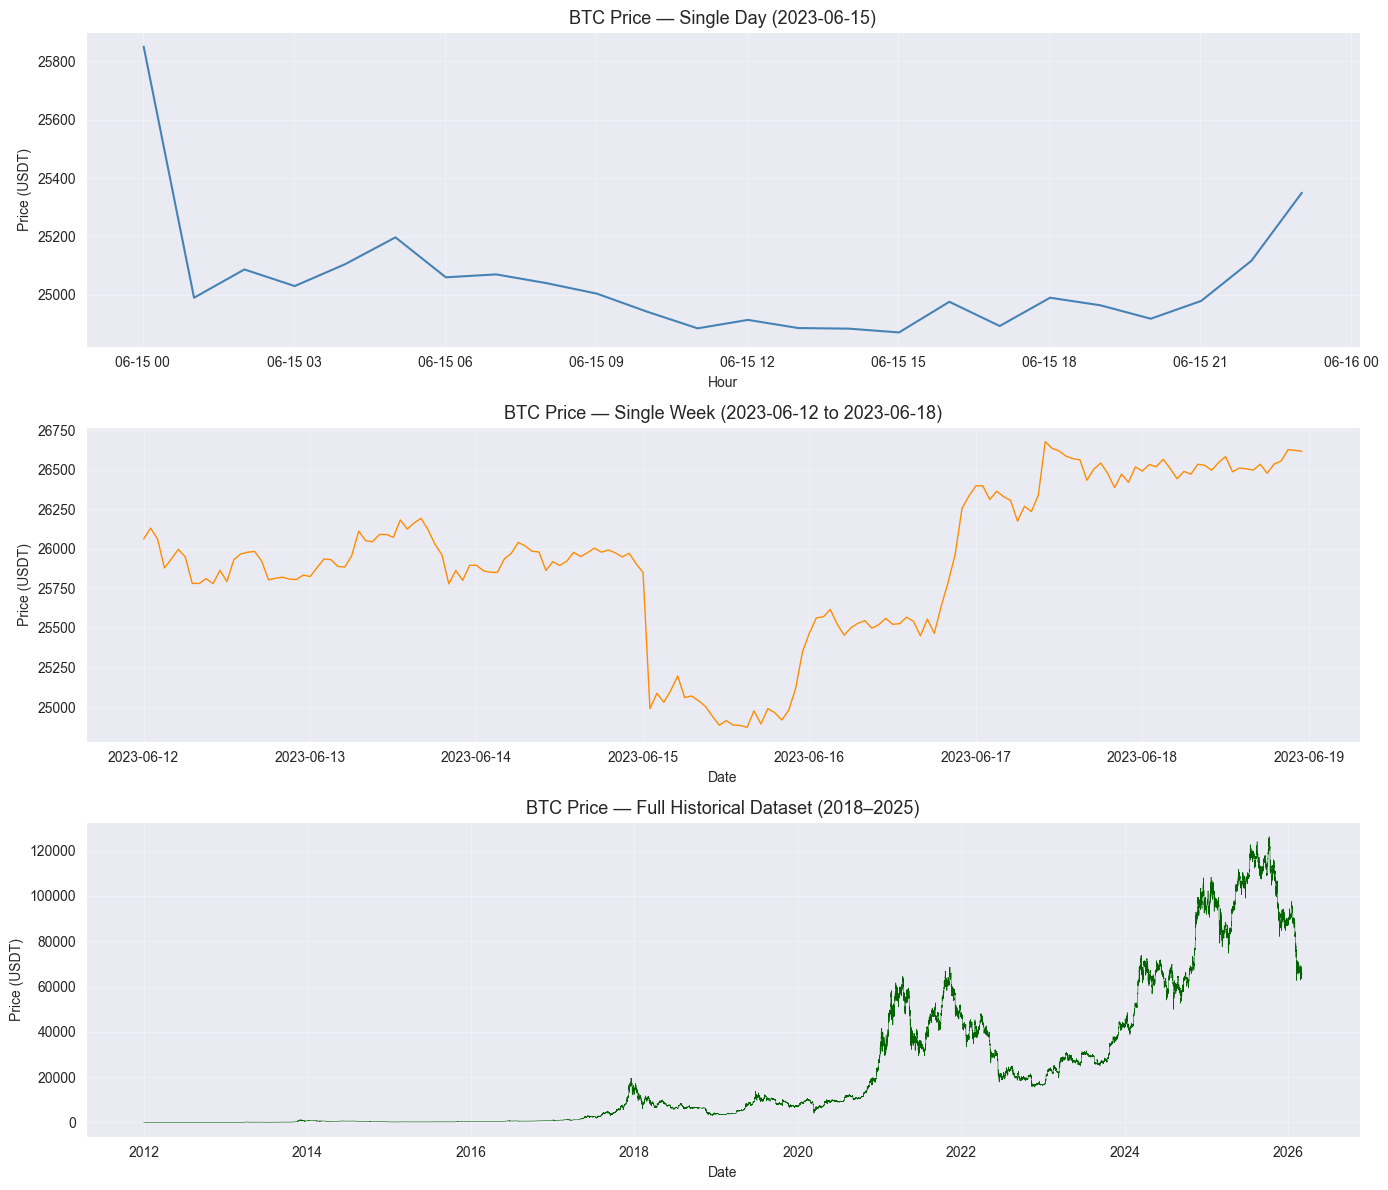

In [18]:
# ============================================================
# EXERCISE 2: Multi-Scale Visualization
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- 2a. Single Day (24 hours) ---
sample_day = '2023-06-15'
day_data = df.loc[sample_day]
axes[0].plot(day_data.index, day_data['Close'], color='steelblue', linewidth=1.5)
axes[0].set_title(f'BTC Price — Single Day ({sample_day})', fontsize=13)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Price (USDT)')
axes[0].grid(True, alpha=0.3)

# --- 2b. Single Week ---
week_start = '2023-06-12'
week_end = '2023-06-18'
week_data = df.loc[week_start:week_end]
axes[1].plot(week_data.index, week_data['Close'], color='darkorange', linewidth=1)
axes[1].set_title(f'BTC Price — Single Week ({week_start} to {week_end})', fontsize=13)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USDT)')
axes[1].grid(True, alpha=0.3)

# --- 2c. Full Dataset ---
axes[2].plot(df.index, df['Close'], color='darkgreen', linewidth=0.4)
axes[2].set_title('BTC Price — Full Historical Dataset (2018–2025)', fontsize=13)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (USDT)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex2_multiscale.png'), dpi=150, bbox_inches='tight')
plt.show()

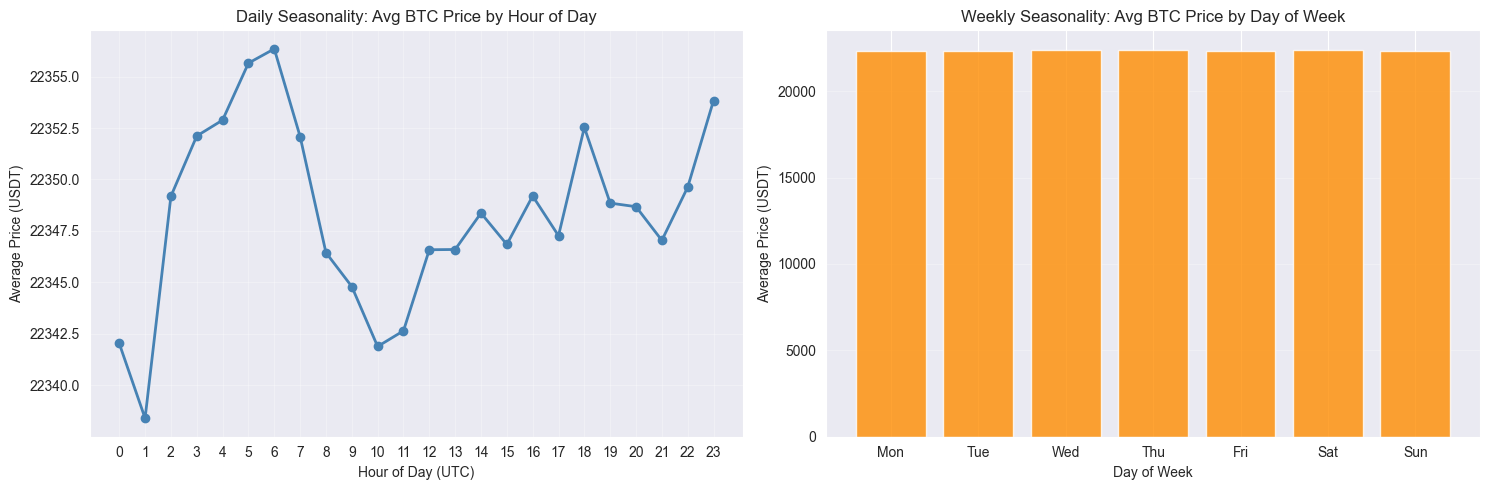


--- 3c. Returns-Based Seasonality (de-trended) ---


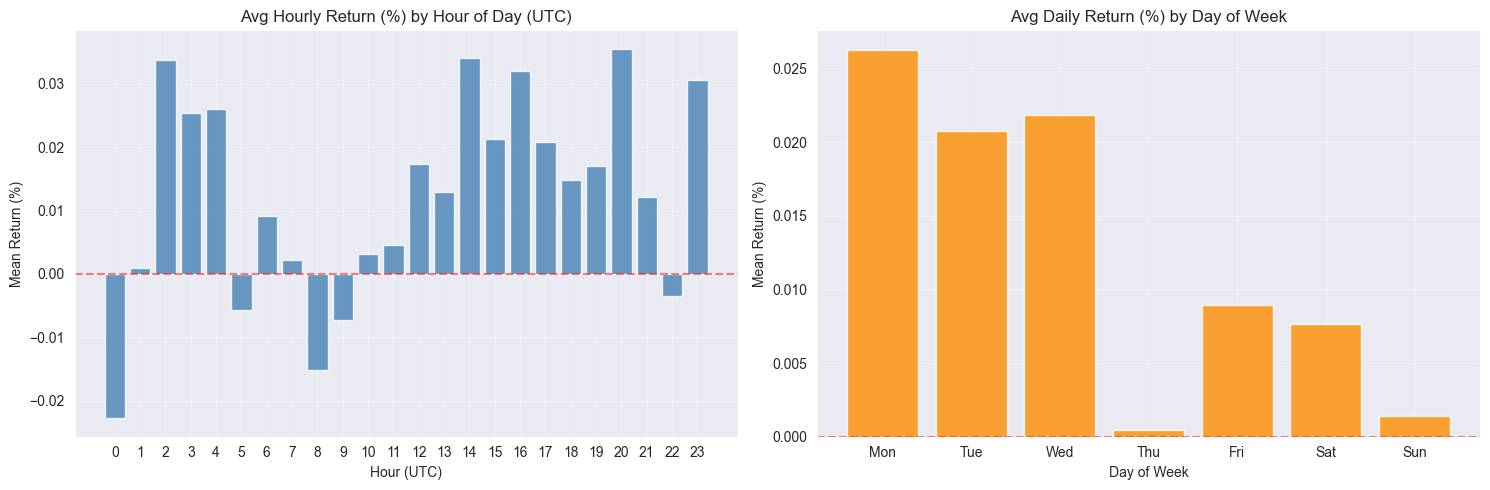


--- 3d. Bitcoin Halving Cycle Analysis ---


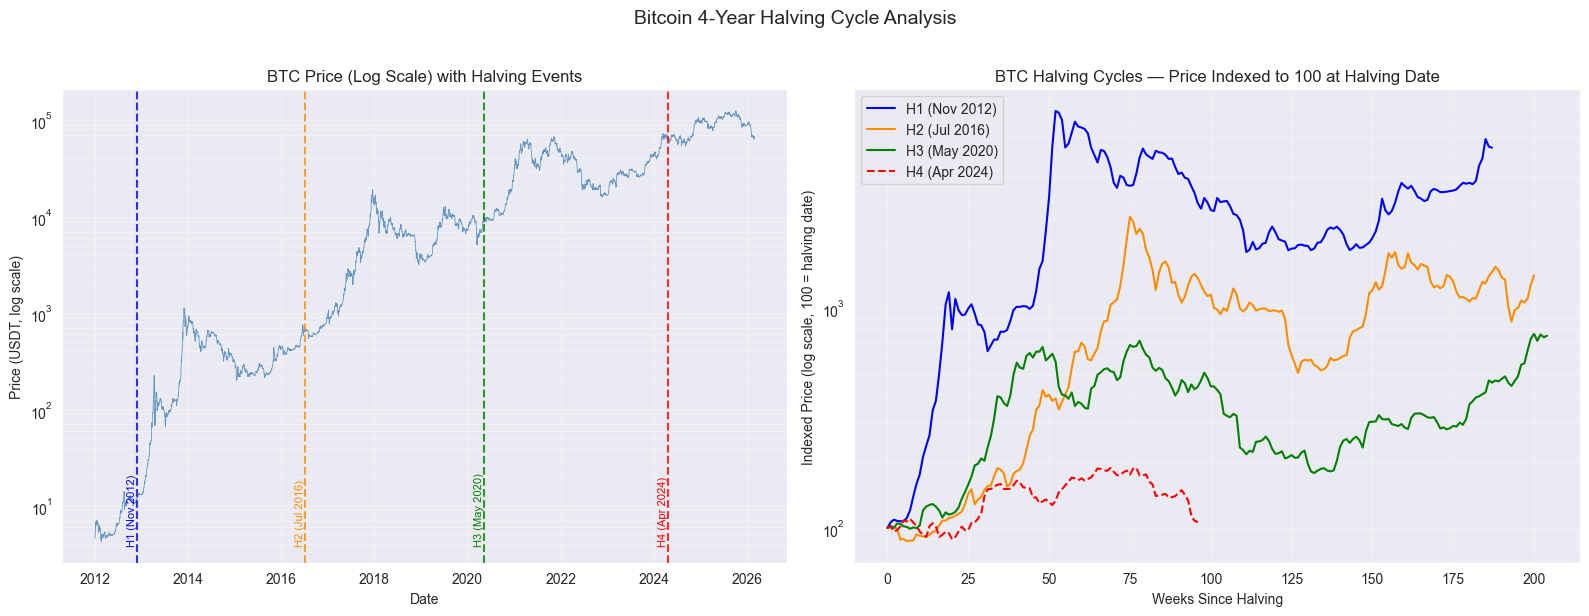


--- 3e. STL Decomposition (weekly, period=52) ---


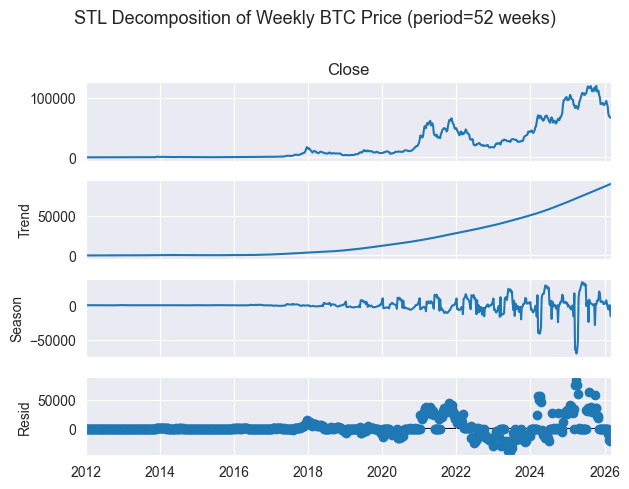

In [19]:
# ============================================================
# EXERCISE 3: Seasonality Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- 3a. Daily Seasonality: Average price by Hour of Day (0-23) ---
# Raw mean price per hour across the full dataset.
hourly_avg = df.groupby(df.index.hour)['Close'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Daily Seasonality: Avg BTC Price by Hour of Day', fontsize=12)
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Average Price (USDT)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

# --- 3b. Weekly Seasonality: Average price by Day of Week ---
daily_means = df.resample('D').mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_avg = daily_means.groupby(daily_means.index.dayofweek)['Close'].mean()
axes[1].bar(range(7), weekly_avg.values, color='darkorange', alpha=0.8)
axes[1].set_title('Weekly Seasonality: Avg BTC Price by Day of Week', fontsize=12)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Price (USDT)')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex3ab_seasonality_price.png'), dpi=150, bbox_inches='tight')

plt.show()

# ============================================================
# 3c. Returns-Based Seasonality (de-trended)
# ============================================================
# Raw price averages (3a/3b) are dominated by the recent high-price era:
# BTC rose from ~$4 (2012) to ~$100K (2025), so the average is entirely
# skewed toward recent years.  Hourly % returns are scale-invariant —
# each bar represents the same concept regardless of the price level,
# making this the correct measure for detecting genuine intraday/intraweek
# seasonality patterns.

print("\n--- 3c. Returns-Based Seasonality (de-trended) ---")
df['Return'] = df['Close'].pct_change()
fig, axes2 = plt.subplots(1, 2, figsize=(15, 5))

hourly_ret = df.groupby(df.index.hour)['Return'].mean() * 100
axes2[0].bar(range(24), hourly_ret.values, color='steelblue', alpha=0.8)
axes2[0].set_title('Avg Hourly Return (%) by Hour of Day (UTC)', fontsize=12)
axes2[0].set_xlabel('Hour (UTC)')
axes2[0].set_ylabel('Mean Return (%)')
axes2[0].set_xticks(range(0, 24))
axes2[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes2[0].grid(True, alpha=0.3)

weekly_ret = df.groupby(df.index.dayofweek)['Return'].mean() * 100
axes2[1].bar(range(7), weekly_ret.values, color='darkorange', alpha=0.8)
axes2[1].set_title('Avg Daily Return (%) by Day of Week', fontsize=12)
axes2[1].set_xlabel('Day of Week')
axes2[1].set_ylabel('Mean Return (%)')
axes2[1].set_xticks(range(7))
axes2[1].set_xticklabels(day_names)
axes2[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex3c_seasonality_returns.png'), dpi=150, bbox_inches='tight')

plt.show()

# Clean up temp column
df.drop(columns=['Return'], inplace=True)

# ============================================================
# 3d. Bitcoin Halving Cycle Analysis
# ============================================================
# Bitcoin undergoes a "halving" every ~4 years: the block reward is cut in half,
# reducing the rate of new supply issuance.  Historically each halving has preceded
# a major bull run, producing self-similar log-linear growth phases.
# Halvings are hardcoded constants — no external fetch required.

print("\n--- 3d. Bitcoin Halving Cycle Analysis ---")
HALVINGS = pd.to_datetime(['2012-11-28', '2016-07-09', '2020-05-11', '2024-04-19'])
HALVING_LABELS = ['H1 (Nov 2012)', 'H2 (Jul 2016)', 'H3 (May 2020)', 'H4 (Apr 2024)']
_cycle_colors = ['blue', 'darkorange', 'green', 'red']

daily_close  = df['Close'].resample('D').mean()
weekly_close = df['Close'].resample('W').mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: full log-scale price + halving vertical lines
ax1.semilogy(daily_close.index, daily_close.values,
             color='steelblue', linewidth=0.6, alpha=0.8)
for i, (date, label) in enumerate(zip(HALVINGS, HALVING_LABELS)):
    ax1.axvline(x=date, color=_cycle_colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    ax1.text(date, ax1.get_ylim()[0] * 1.5, label,
             color=_cycle_colors[i], fontsize=8, rotation=90, va='bottom', ha='right')
ax1.set_title('BTC Price (Log Scale) with Halving Events', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USDT, log scale)')
ax1.grid(True, alpha=0.3, which='both')

# Right: cycle overlay — price indexed to 100 at each halving date
for i, halving_date in enumerate(HALVINGS):
    next_date = HALVINGS[i + 1] if i < len(HALVINGS) - 1 else weekly_close.index[-1]
    mask  = (weekly_close.index >= halving_date) & (weekly_close.index < next_date)
    cycle = weekly_close[mask].dropna()
    if len(cycle) == 0:
        continue
    normalized = cycle / cycle.iloc[0] * 100
    weeks = range(len(normalized))
    ls = '--' if i == len(HALVINGS) - 1 else '-'   # dashed for H4 (incomplete)
    ax2.semilogy(weeks, normalized.values, linestyle=ls, color=_cycle_colors[i],
                 label=HALVING_LABELS[i], linewidth=1.5)

ax2.set_title('BTC Halving Cycles — Price Indexed to 100 at Halving Date', fontsize=12)
ax2.set_xlabel('Weeks Since Halving')
ax2.set_ylabel('Indexed Price (log scale, 100 = halving date)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, which='both')

plt.suptitle('Bitcoin 4-Year Halving Cycle Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex3d_halving_cycles.png'), dpi=150, bbox_inches='tight')

plt.show()

# ============================================================
# 3e. STL Decomposition (weekly data, period=52)
# ============================================================
# STL (Seasonal-Trend decomposition using Loess) decomposes the weekly price
# series into: Trend (slow-moving level), Seasonal (period=52 → yearly cycle),
# and Residual.  robust=True downweights outliers — important for BTC crash
# events which would otherwise distort the seasonal component.

print("\n--- 3e. STL Decomposition (weekly, period=52) ---")
from statsmodels.tsa.seasonal import STL

weekly_close_stl = df['Close'].resample('W').mean().dropna()
stl    = STL(weekly_close_stl, period=52, robust=True)
result = stl.fit()

fig = result.plot()
plt.suptitle('STL Decomposition of Weekly BTC Price (period=52 weeks)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex3e_stl_decomposition.png'), dpi=150, bbox_inches='tight')

plt.show()

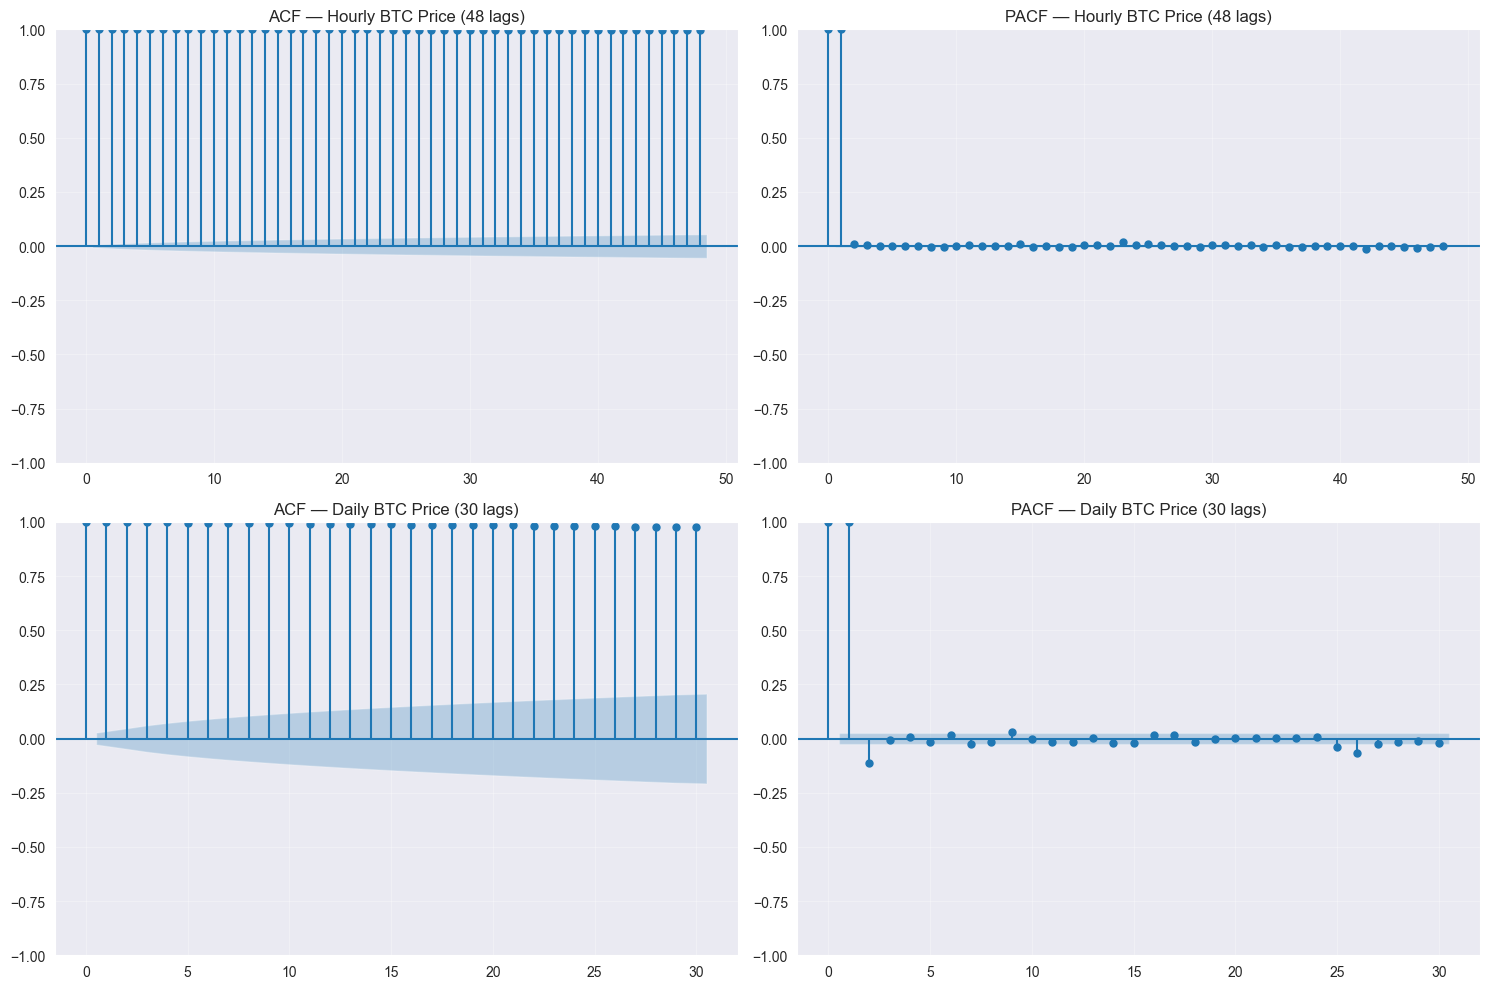

In [20]:
# ============================================================
# EXERCISE 4: Statistical Analysis — ACF / PACF
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 4a. Hourly ACF/PACF (lags=48) ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(df['Close'].dropna(), lags=48, ax=axes[0, 0], title='ACF — Hourly BTC Price (48 lags)')
plot_pacf(df['Close'].dropna(), lags=48, ax=axes[0, 1], title='PACF — Hourly BTC Price (48 lags)', method='ywm')

# --- 4b. Daily resampled ACF/PACF (lags=30) ---
daily_df = df.resample('D').mean()

plot_acf(daily_df['Close'].dropna(), lags=30, ax=axes[1, 0], title='ACF — Daily BTC Price (30 lags)')
plot_pacf(daily_df['Close'].dropna(), lags=30, ax=axes[1, 1], title='PACF — Daily BTC Price (30 lags)', method='ywm')

for ax_row in axes:
    for ax in ax_row:
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex4_acf_pacf.png'), dpi=150, bbox_inches='tight')

plt.show()

Weekly data: 740 rows
Range: 2012-01-01 00:00:00 → 2026-03-01 00:00:00
Train: 688 weeks | Test: 52 weeks
Cutoff: 2025-03-02


10:41:31 - cmdstanpy - INFO - Chain [1] start processing
10:41:31 - cmdstanpy - INFO - Chain [1] done processing



--- Prophet Baseline Results ---
MAE:  $27,648.70
RMSE: $34,069.02


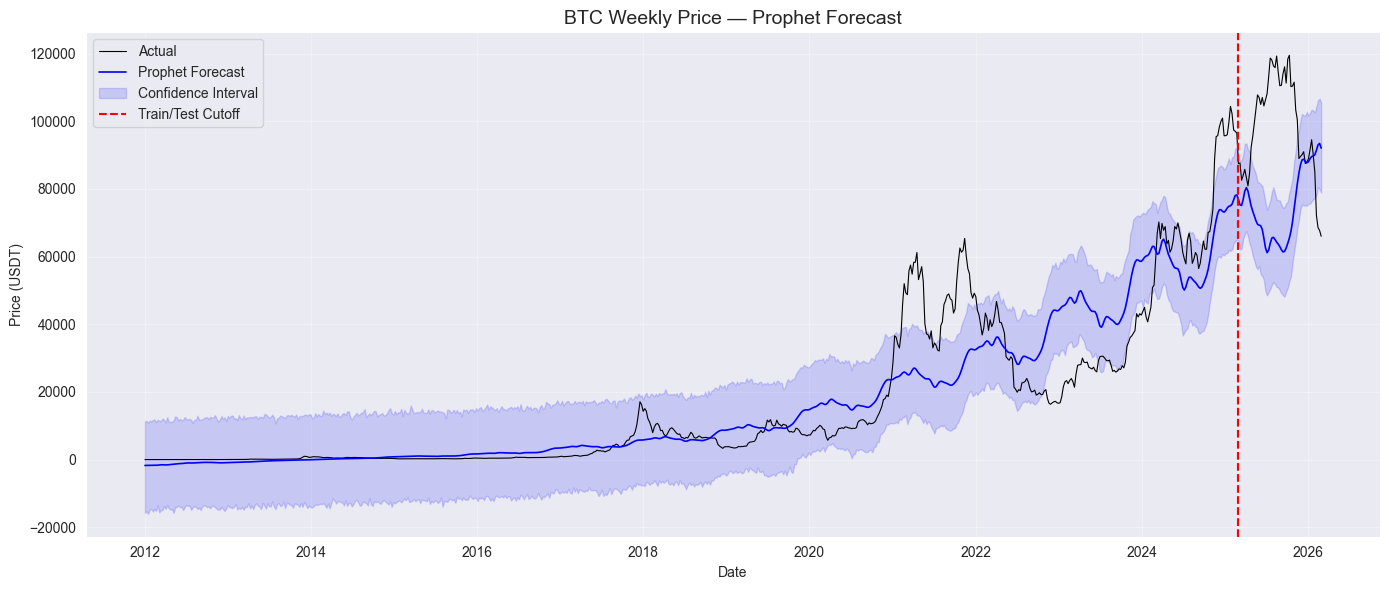

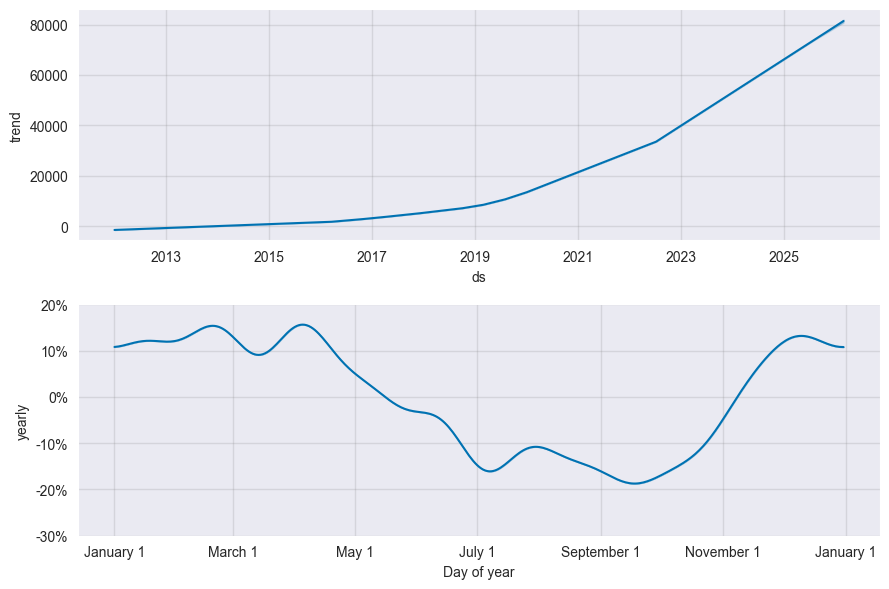

10:41:32 - cmdstanpy - INFO - Chain [1] start processing



--- Prophet Experiment: Higher Changepoint Flexibility ---


10:41:32 - cmdstanpy - INFO - Chain [1] done processing
10:41:32 - cmdstanpy - INFO - Chain [1] start processing
10:41:32 - cmdstanpy - INFO - Chain [1] done processing


MAE:  $25,684.06
RMSE: $28,383.93
MAE change: -7.1%

--- 5h. Walk-Forward Validation (4 chunks) ---
Chunk 1/4: training on 688 weeks, forecasting 13 weeks (2025-03-09 → 2025-06-01)


10:41:33 - cmdstanpy - INFO - Chain [1] start processing


...

10:41:33 - cmdstanpy - INFO - Chain [1] done processing
10:41:33 - cmdstanpy - INFO - Chain [1] start processing


Chunk 3/4: training on 714 weeks, forecasting 13 weeks (2025-09-07 → 2025-11-30)


10:41:33 - cmdstanpy - INFO - Chain [1] done processing
10:41:33 - cmdstanpy - INFO - Chain [1] start processing


Chunk 4/4: training on 727 weeks, forecasting 13 weeks (2025-12-07 → 2026-03-01)


10:41:33 - cmdstanpy - INFO - Chain [1] done processing


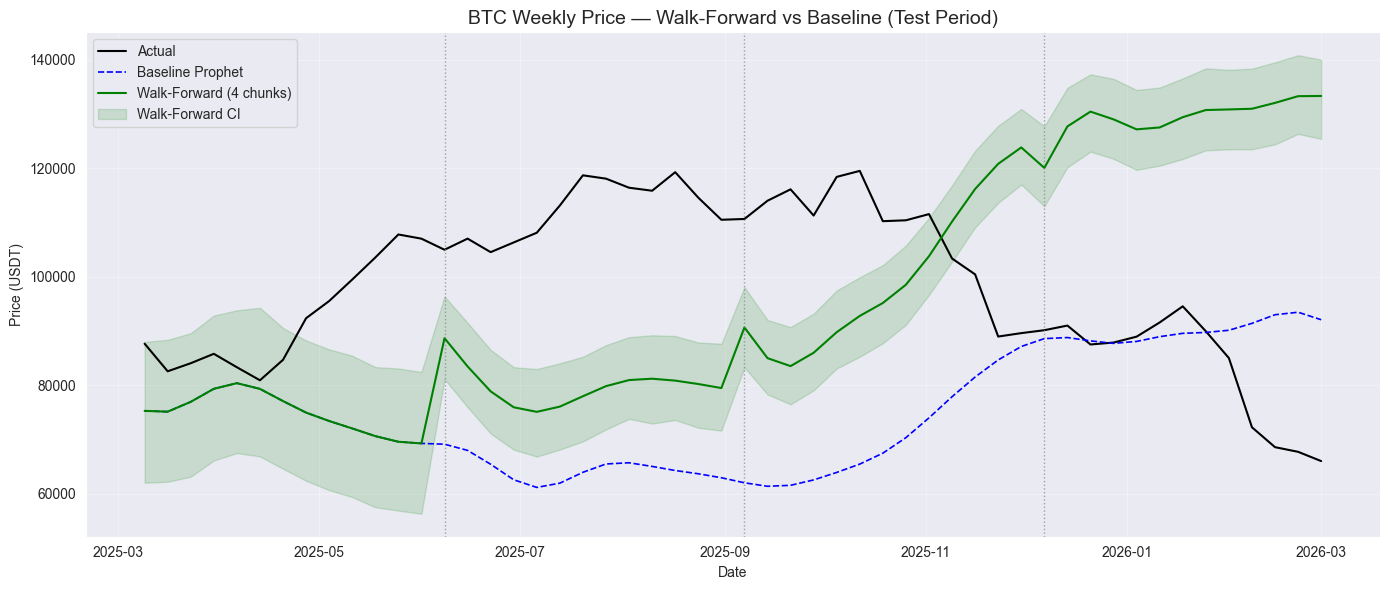

10:41:34 - cmdstanpy - INFO - Chain [1] start processing
10:41:34 - cmdstanpy - INFO - Chain [1] done processing



--- 5i. Halving-Aware Prophet (4-year seasonality) ---
MAE:  $28,493.91
RMSE: $34,025.33

--- Model Comparison (all models) ---
Model                                   MAE         RMSE
Baseline Prophet               $     27,649  $     34,069
Flexible Changepoints          $     25,684  $     28,384
Walk-Forward (4 chunks)        $     29,365  $     33,146
Halving-Aware (4yr cycle)      $     28,494  $     34,025


In [21]:
# ============================================================
# EXERCISE 5: Forecasting with Prophet
# ============================================================
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 5a. Resample to weekly averages (Close price only)
weekly_df = df['Close'].resample('W').mean().reset_index()
weekly_df.columns = ['ds', 'y']
print(f"Weekly data: {len(weekly_df)} rows")
print(f"Range: {weekly_df['ds'].min()} → {weekly_df['ds'].max()}")

# 5b. Train/Test split: everything except last 52 weeks for training
cutoff_date = weekly_df['ds'].max() - pd.Timedelta(weeks=52)
train = weekly_df[weekly_df['ds'] <= cutoff_date]
test = weekly_df[weekly_df['ds'] > cutoff_date]
print(f"Train: {len(train)} weeks | Test: {len(test)} weeks")
print(f"Cutoff: {cutoff_date.date()}")

# 5c. Train Prophet model (baseline)
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # weekly avg removes intra-week patterns
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # default regularization
    seasonality_mode='multiplicative'  # BTC has multiplicative seasonality (% swings)
)
model.fit(train)

# 5d. Forecast next 52 weeks
future = model.make_future_dataframe(periods=52, freq='W')
forecast = model.predict(future)

# 5e. Evaluate on test set
forecast_test = forecast[forecast['ds'].isin(test['ds'])]
merged = test.merge(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

mae = mean_absolute_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
print(f"\n--- Prophet Baseline Results ---")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

# 5f. Plot forecast
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(weekly_df['ds'], weekly_df['y'], label='Actual', color='black', linewidth=0.8)
ax.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='blue', linewidth=1.2)
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='blue', label='Confidence Interval')
ax.axvline(x=cutoff_date, color='red', linestyle='--', label='Train/Test Cutoff')
ax.set_title('BTC Weekly Price — Prophet Forecast', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USDT)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex5f_prophet_forecast.png'), dpi=150, bbox_inches='tight')

plt.show()

# Prophet components
model.plot_components(forecast)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex5f_prophet_components.png'), dpi=150, bbox_inches='tight')

plt.show()

# --- 5g. Experiment: More flexible changepoints ---
print("\n--- Prophet Experiment: Higher Changepoint Flexibility ---")
model2 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,  # MORE flexible to trend changes
    seasonality_mode='multiplicative',
    n_changepoints=30
)
model2.fit(train)
forecast2 = model2.predict(future)
forecast_test2 = forecast2[forecast2['ds'].isin(test['ds'])]
merged2 = test.merge(forecast_test2[['ds', 'yhat']], on='ds')
mae2 = mean_absolute_error(merged2['y'], merged2['yhat'])
rmse2 = np.sqrt(mean_squared_error(merged2['y'], merged2['yhat']))
print(f"MAE:  ${mae2:,.2f}")
print(f"RMSE: ${rmse2:,.2f}")
print(f"MAE change: {((mae2 - mae) / mae * 100):+.1f}%")

# ============================================================
# 5h. Walk-Forward Validation (4 chunks, expanding window)
# ============================================================
# Instead of one static forecast for the full 52-week test period,
# we retrain Prophet 4 times — once before each ~13-week chunk —
# using all data observed up to that point (expanding window).
# This better handles BTC's frequent structural breaks.

print("\n--- 5h. Walk-Forward Validation (4 chunks) ---")

n_chunks = 4
chunk_size = len(test) // n_chunks   # ~13 weeks; last chunk absorbs any remainder
wf_preds = []

for i in range(n_chunks):
    start_idx = i * chunk_size
    end_idx   = start_idx + chunk_size if i < n_chunks - 1 else len(test)
    chunk     = test.iloc[start_idx:end_idx]

    # Expanding window: all observed weeks before this chunk's start date
    train_exp = weekly_df[weekly_df['ds'] < chunk['ds'].iloc[0]]
    print(f"Chunk {i+1}/{n_chunks}: training on {len(train_exp)} weeks, "
          f"forecasting {len(chunk)} weeks "
          f"({chunk['ds'].iloc[0].date()} → {chunk['ds'].iloc[-1].date()})")

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
        seasonality_mode='multiplicative'
    )
    m.fit(train_exp)

    steps = end_idx - start_idx
    future_c = m.make_future_dataframe(periods=steps, freq='W')
    fc = m.predict(future_c)
    wf_preds.append(fc[fc['ds'].isin(chunk['ds'])])

wf_df     = pd.concat(wf_preds).reset_index(drop=True)
merged_wf = test.merge(wf_df[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')
mae_wf    = mean_absolute_error(merged_wf['y'], merged_wf['yhat'])
rmse_wf   = np.sqrt(mean_squared_error(merged_wf['y'], merged_wf['yhat']))

# --- Plot: test period only ---
# Chunk boundary dates for vertical dashed lines
chunk_starts = [test.iloc[i * chunk_size]['ds'] for i in range(1, n_chunks)]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test['ds'], test['y'],
        label='Actual', color='black', linewidth=1.5)
ax.plot(merged['ds'], merged['yhat'],
        label='Baseline Prophet', color='blue', linewidth=1.2, linestyle='--')
ax.plot(merged_wf['ds'], merged_wf['yhat'],
        label='Walk-Forward (4 chunks)', color='green', linewidth=1.5)
ax.fill_between(merged_wf['ds'],
                merged_wf['yhat_lower'], merged_wf['yhat_upper'],
                alpha=0.15, color='green', label='Walk-Forward CI')

for boundary in chunk_starts:
    ax.axvline(x=boundary, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax.set_title('BTC Weekly Price — Walk-Forward vs Baseline (Test Period)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USDT)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'ex5h_walkforward.png'), dpi=150, bbox_inches='tight')

plt.show()

# ============================================================
# 5i. Halving-Aware Prophet (4-year cycle as custom seasonality)
# ============================================================
# Bitcoin's dominant multi-year seasonality is the 4-year halving cycle.
# We encode it as a custom Fourier seasonality with period ≈ 208.7 weeks
# (365.25 * 4 / 7).  fourier_order=3 provides 3 sin/cos pairs, capturing
# the asymmetric shape of the cycle (slow accumulation, sharp peak, crash).

print("\n--- 5i. Halving-Aware Prophet (4-year seasonality) ---")

model3 = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)
# Add 4-year (≈208.7 weeks) Fourier seasonality to encode halving cycle
model3.add_seasonality(name='halving_cycle', period=365.25 * 4 / 7, fourier_order=3)
model3.fit(train)

forecast3 = model3.predict(future)
forecast_test3 = forecast3[forecast3['ds'].isin(test['ds'])]
merged3 = test.merge(forecast_test3[['ds', 'yhat']], on='ds')
mae3  = mean_absolute_error(merged3['y'], merged3['yhat'])
rmse3 = np.sqrt(mean_squared_error(merged3['y'], merged3['yhat']))
print(f"MAE:  ${mae3:,.2f}")
print(f"RMSE: ${rmse3:,.2f}")

# --- Updated 4-model comparison table ---
print("\n--- Model Comparison (all models) ---")
print(f"{'Model':<30} {'MAE':>12} {'RMSE':>12}")
print(f"{'Baseline Prophet':<30} ${mae:>11,.0f}  ${rmse:>11,.0f}")
print(f"{'Flexible Changepoints':<30} ${mae2:>11,.0f}  ${rmse2:>11,.0f}")
print(f"{'Walk-Forward (4 chunks)':<30} ${mae_wf:>11,.0f}  ${rmse_wf:>11,.0f}")
print(f"{'Halving-Aware (4yr cycle)':<30} ${mae3:>11,.0f}  ${rmse3:>11,.0f}")

Weekly time series: 740 observations

ADF Test (original): Statistic=-0.4443, p-value=0.9024
→ Non-stationary
ADF Test (1st diff): Statistic=-7.0704, p-value=0.0000
→ Stationary

Train: 688 weeks | Test: 52 weeks

Fitting SARIMA(1,1,1)(1,0,1,52)... this may take a few minutes...
                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  688
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 52)   Log Likelihood               -5670.772
Date:                            Mon, 02 Mar 2026   AIC                          11351.543
Time:                                    10:41:37   BIC                          11373.796
Sample:                                01-01-2012   HQIC                         11360.185
                                     - 03-02-2025                                         
Covariance Type:                              opg                                  

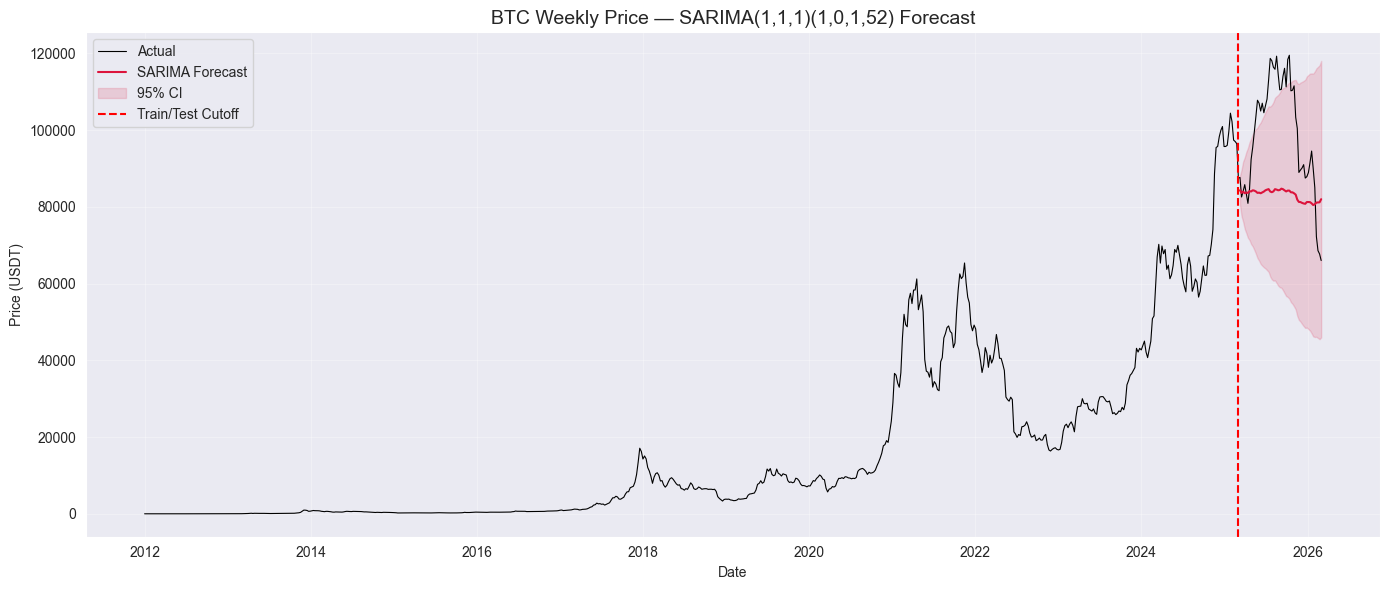

In [22]:
# ============================================================
# EXERCISE 6 (BONUS): SARIMA Forecasting
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Use weekly resampled data (as recommended to avoid long runtimes)
weekly_ts = df.resample('W').mean()['Close']
print(f"Weekly time series: {len(weekly_ts)} observations")

# --- Check stationarity ---
adf_result = adfuller(weekly_ts.dropna())
print(f"\nADF Test (original): Statistic={adf_result[0]:.4f}, p-value={adf_result[1]:.4f}")
print("→ Non-stationary" if adf_result[1] > 0.05 else "→ Stationary")

# Differenced
adf_diff = adfuller(weekly_ts.diff().dropna())
print(f"ADF Test (1st diff): Statistic={adf_diff[0]:.4f}, p-value={adf_diff[1]:.4f}")
print("→ Non-stationary" if adf_diff[1] > 0.05 else "→ Stationary")

# --- Train/Test Split ---
cutoff = len(weekly_ts) - 52
train_ts = weekly_ts.iloc[:cutoff]
test_ts = weekly_ts.iloc[cutoff:]
print(f"\nTrain: {len(train_ts)} weeks | Test: {len(test_ts)} weeks")

# --- Fit SARIMA ---
# SARIMA(p,d,q)(P,D,Q,s) — with d=1 for differencing, s=52 is too heavy,
# so we use a simpler seasonal period or no seasonal component.
# For weekly BTC data, s=52 (yearly seasonality) but we keep it simple.
print("\nFitting SARIMA(1,1,1)(1,0,1,52)... this may take a few minutes...")

try:
    sarima_model = SARIMAX(
        train_ts,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_result = sarima_model.fit(disp=False, maxiter=200)
    print(sarima_result.summary().tables[0])

    # Forecast
    sarima_forecast = sarima_result.get_forecast(steps=52)
    sarima_pred = sarima_forecast.predicted_mean
    sarima_ci = sarima_forecast.conf_int()

    # Evaluate
    mae_s = mean_absolute_error(test_ts.values[:len(sarima_pred)], sarima_pred.values)
    rmse_s = np.sqrt(mean_squared_error(test_ts.values[:len(sarima_pred)], sarima_pred.values))
    print(f"\nSARIMA Results:")
    print(f"MAE:  ${mae_s:,.2f}")
    print(f"RMSE: ${rmse_s:,.2f}")

    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(weekly_ts.index, weekly_ts.values, label='Actual', color='black', linewidth=0.8)
    ax.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast',
            color='crimson', linewidth=1.5)
    ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                    alpha=0.15, color='crimson', label='95% CI')
    ax.axvline(x=train_ts.index[-1], color='red', linestyle='--', label='Train/Test Cutoff')
    ax.set_title('BTC Weekly Price — SARIMA(1,1,1)(1,0,1,52) Forecast', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USDT)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'ex6_sarima_forecast.png'), dpi=150, bbox_inches='tight')

    plt.show()

except Exception as e:
    print(f"SARIMA with s=52 failed: {e}")
    print("\nFalling back to simpler ARIMA(2,1,2) without seasonal component...")

    arima_model = SARIMAX(train_ts, order=(2, 1, 2),
                          enforce_stationarity=False, enforce_invertibility=False)
    arima_result = arima_model.fit(disp=False)

    arima_forecast = arima_result.get_forecast(steps=52)
    arima_pred = arima_forecast.predicted_mean
    arima_ci = arima_forecast.conf_int()

    mae_a = mean_absolute_error(test_ts.values[:len(arima_pred)], arima_pred.values)
    rmse_a = np.sqrt(mean_squared_error(test_ts.values[:len(arima_pred)], arima_pred.values))
    print(f"ARIMA MAE:  ${mae_a:,.2f}")
    print(f"ARIMA RMSE: ${rmse_a:,.2f}")

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(weekly_ts.index, weekly_ts.values, label='Actual', color='black', linewidth=0.8)
    ax.plot(arima_pred.index, arima_pred.values, label='ARIMA(2,1,2) Forecast',
            color='crimson', linewidth=1.5)
    ax.fill_between(arima_ci.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1],
                    alpha=0.15, color='crimson')
    ax.axvline(x=train_ts.index[-1], color='red', linestyle='--', label='Cutoff')
    ax.set_title('BTC Weekly Price — ARIMA(2,1,2) Forecast', fontsize=14)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USDT)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'ex6_arima_forecast.png'), dpi=150, bbox_inches='tight')

    plt.show()